In [1]:
import numpy as np
import matplotlib.pyplot as plt

from block_encoding import generate_laplacian_block_encoding, get_circuit_unitary
from sunderhauff_be import sunderhauff_block_encoding
from laplacian_structures import generate_laplacian
from camps_be import camps_block_encoding
from utils import prepare_v_vector, convert_vector_to_tensor
from qiskit import transpile

Grid spacing for x dimension: 2^-1
Grid spacing for x dimension: 2^-2
Grid spacing for x dimension: 2^-3


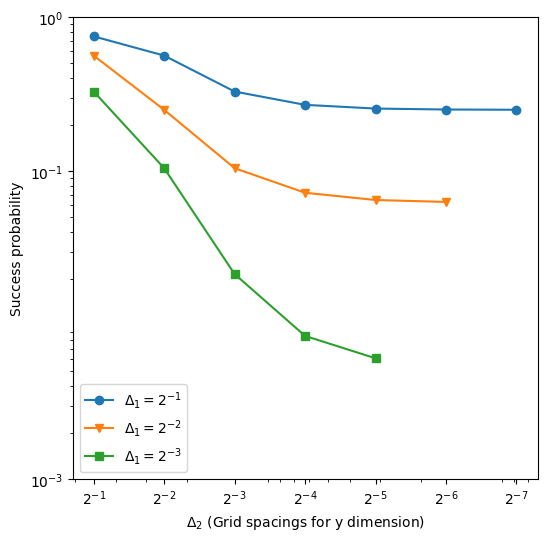

In [2]:
# Success probability vs (uneven) grid spacings
@np.vectorize
def v(x, y):
    return np.sin(2 * np.pi * (x + y))

nq1s = range(1, 4)

plt.figure(figsize=(6, 6))
markers = ["o", "v", "s"]

for i, nq1 in enumerate(nq1s):
    print(f"Grid spacing for x dimension: 2^{-nq1}")
    nq2s = range(1, 9 - nq1)

    # Grid spacings for y dimension
    deltas_2 = [2**-nq for nq in nq2s]
    succ_probs = []

    for nq2 in nq2s:
        nqs = [nq1, nq2]
        v_vec = prepare_v_vector(nqs, v)
        qc = generate_laplacian_block_encoding(nqs, bcs=["periodic", "periodic"], vs=v_vec)
        unitary = get_circuit_unitary(qc, nqs)
        succ_probs.append(np.linalg.norm(unitary[:, 0]) ** 2)

    plt.plot(deltas_2, succ_probs, marker=markers[i], label=f"$\\Delta_1 = 2^{{{-nq1}}}$")

plt.xscale("log")
plt.xticks([2**-i for i in range(1, 8)], labels=[f"$2^{{-{i}}}$" for i in range(1, 8)])
plt.xlabel("$\\Delta_2$ (Grid spacings for y dimension)")
plt.gca().invert_xaxis()

plt.yscale("log")
plt.yticks([1] + [10**i for i in range(-3, 0, 2)])
plt.ylabel("Success probability")

plt.legend()
plt.show()


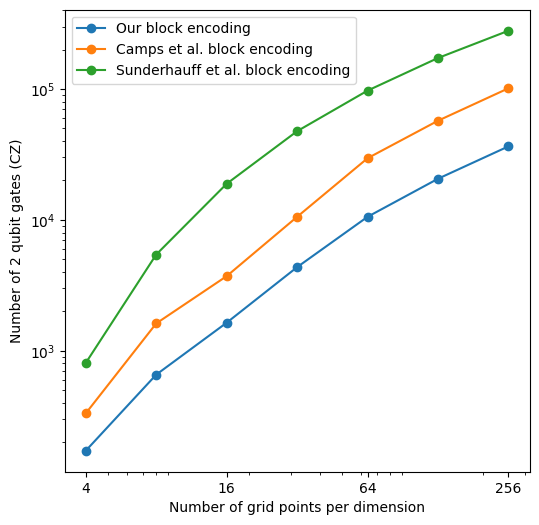

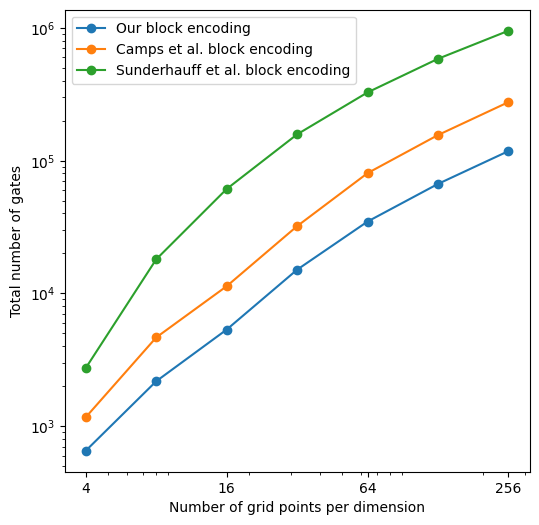

In [10]:
# Number of 2 qubit gates when circuit is transpiled with Heron basis gates set for a DD Laplacian
basis_gates = ["cz", "id", "rx", "rz", "rzz", "sx", "x"]

nq = list(range(2, 9))
npoints = 2**np.array(nq)

our_be_2qg = []
camps_be_2qg = []
sunderhauff_be_2qg = []

our_be_total_gates = []
camps_be_total_gates = []
sunderhauff_be_total_gates = []


for nq1 in nq:
    # Our block encoding
    qc = generate_laplacian_block_encoding([nq1, nq1], save_unitary=False)
    transpiled = transpile(qc, basis_gates=basis_gates)
    lap = generate_laplacian((2**nq1, 2**nq1), analytic_normalize=True)

    counts = transpiled.count_ops()
    cz_count = counts["cz"]
    our_be_2qg.append(cz_count)
    our_be_total_gates.append(sum(counts.values()))

    # Camps et al. block encoding
    qc = camps_block_encoding(nq1, ["dirichlet", "dirichlet"], save_unitary=False)
    transpiled = transpile(qc, basis_gates=basis_gates)

    counts = transpiled.count_ops()
    cz_count = counts["cz"]
    camps_be_2qg.append(cz_count)
    camps_be_total_gates.append(sum(counts.values()))

    # Sunderhauff et al. block encoding
    qc = sunderhauff_block_encoding(2**nq1, 2**nq1, lap, save_unitary=False)
    transpiled = transpile(qc, basis_gates=basis_gates)

    counts = transpiled.count_ops()
    cz_count = counts["cz"]
    sunderhauff_be_2qg.append(cz_count)
    sunderhauff_be_total_gates.append(sum(counts.values()))


plt.figure(figsize=(6, 6))
plt.plot(npoints, our_be_2qg, "o-", label="Our block encoding")
plt.plot(npoints, camps_be_2qg, "o-", label="Camps et al. block encoding")
plt.plot(npoints, sunderhauff_be_2qg, "o-", label="Sunderhauff et al. block encoding")
plt.xscale("log")
plt.xlabel("Number of grid points per dimension")
plt.yscale("log")
plt.ylabel("Number of 2 qubit gates (CZ)")
plt.xticks(npoints[::2], labels=npoints[::2])
plt.legend()
plt.show()


plt.figure(figsize=(6, 6))
plt.plot(npoints, our_be_total_gates, "o-", label="Our block encoding")
plt.plot(npoints, camps_be_total_gates, "o-", label="Camps et al. block encoding")
plt.plot(npoints, sunderhauff_be_total_gates, "o-", label="Sunderhauff et al. block encoding")
plt.xscale("log")
plt.xlabel("Number of grid points per dimension")
plt.yscale("log")
plt.ylabel("Total number of gates")
plt.xticks(npoints[::2], labels=npoints[::2])
plt.legend()
plt.show()